In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
# Load built-in Titanic dataset
df = sns.load_dataset('titanic')

# Show first 5 rows
print(df.head())


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [8]:
# Check data types and missing values
print(df.info())

# Summary statistics for numeric columns
print(df.describe())

# Check for duplicates
print(df.duplicated().sum())

# Count missing values per column
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
         survived      pclass         age       sibsp       parch        f

In [10]:
# Fill missing Age with median
df['age'].fillna(df['age'].median(), inplace=True)

# Fill missing Embarked with mode
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Drop Cabin (too many missing values)
df.drop('deck', axis=1, inplace=True)  # Seaborn Titanic has 'deck' instead of 'cabin'

# Drop rows with missing Embark town just in case
df.dropna(subset=['embark_town'], inplace=True)


C:\Users\siddu\AppData\Local\Temp\ipykernel_39928\3654743842.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\siddu\AppData\Local\Temp\ipykernel_39928\3654743842.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [11]:
# Convert categorical columns to numeric
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

# Convert 'class' and 'who' if needed (optional)
df = pd.get_dummies(df, columns=['class', 'who'], drop_first=True)



In [ ]:
df.drop_duplicates(inplace=True)


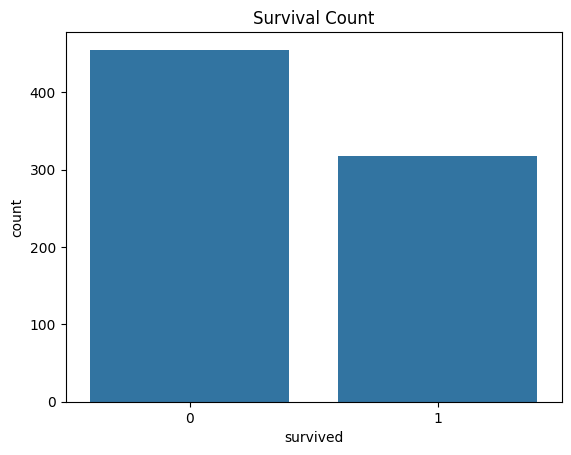

In [13]:
sns.countplot(x='survived', data=df)
plt.title('Survival Count')
plt.show()


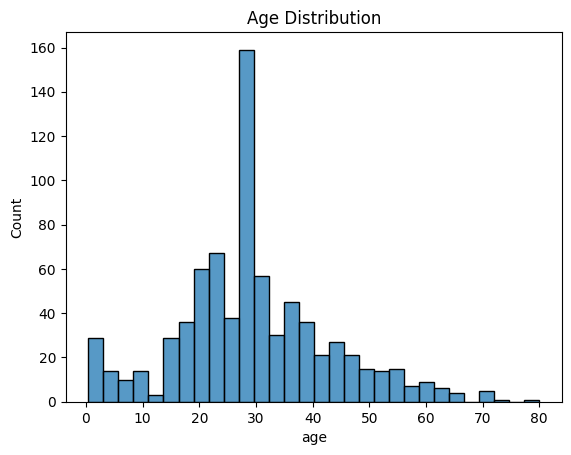

In [15]:
sns.histplot(df['age'], bins=30)
plt.title('Age Distribution')
plt.show()


In [17]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])


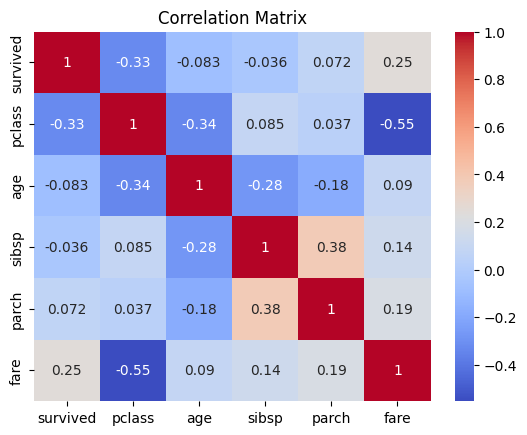

In [18]:
corr = df_numeric.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


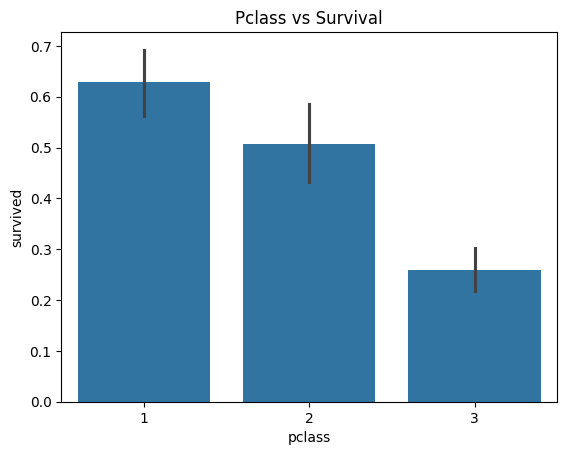

In [19]:
sns.barplot(x='pclass', y='survived', data=df)
plt.title('Pclass vs Survival')
plt.show()


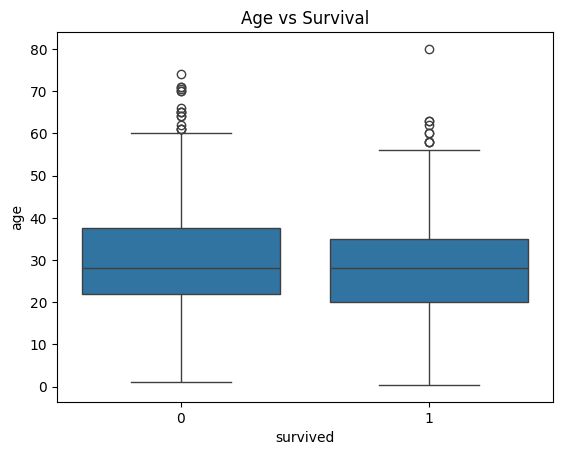

In [20]:
sns.boxplot(x='survived', y='age', data=df)
plt.title('Age vs Survival')
plt.show()
